# WRI Aqueduct riverine flood risk — a guided tour

This notebook teaches the [`aqueduct`](../../reference/aqueduct/introduction.md) backend: how to fetch **WRI Aqueduct Global Flood Analyzer (2015)** riverine flood-risk data and explore it. The data is public (`files.wri.org`, CC-BY-4.0, no credentials): the expected exposure of **GDP**, **population**, and **urban area** to river flooding, aggregated by admin unit.

By the end you will be able to: pick a metric, year, scenario and flood magnitude; map and rank the exposure; compare a baseline against a future projection; read the full return-period curve; filter by country or bbox; and get a plain table.

> This is the flood **impact/exposure** layer. The flood **hazard** depth rasters are a separate product, already reachable via the `gee` backend (`WRI/Aqueduct_Flood_Hazard_Maps/V2`). The richer 2020 product (coastal, 2050/2080, city) is not freely downloadable and is out of scope.

## The request axes

A request is a point in this small grid:

| Argument | Meaning | Values |
|---|---|---|
| `admin_level` | aggregation unit | `country` (default), `state`, `basin` |
| `metric` | what is exposed | `population_affected`, `gdp_affected`, `urban_damage` |
| `year` | baseline or projection | `2010`, `2030` |
| `scenario` | climate x socio-economic | `baseline` (2010); `ssp2-rcp8p5` etc. (2030) |
| `return_period` | flood magnitude (yr) | any of 2 … 1000, a list, or all nine |

`download()` returns a pyramids `FeatureCollection` (a `geopandas.GeoDataFrame`).

## Setup

Imports and a single notebook-relative cache/output dir (`out/`, gitignored).

In [1]:
from earthlens.core import EarthLens
import matplotlib.pyplot as plt

DATA = "out"

2026-08-09 23:19:34 | INFO | pyramids.base.config | Logging is configured.


## Quickstart — map the population exposed

The shortest end-to-end call: country-level **population affected** under the 2030 SSP2+RCP8.5 projection, for the 100-year flood. The first call downloads the ~7 MB country shapefile and caches it under `out/`; every later call in this notebook reuses that cache.

In [2]:
pop30 = EarthLens(
    "aqueduct", admin_level="country", metric="population_affected",
    year=2030, scenario="ssp2-rcp8p5", return_period=100, path=DATA, cache_dir=DATA,
).download()

print(len(pop30), "countries |", list(pop30.columns))

2026-08-09 23:19:36.681 | INFO     | earthlens.aqueduct.backend:_cached_zip:301 - Aqueduct: using cached aqueduct_global_flood_risk_data_by_country_20150304.zip


2026-08-09 23:19:37.245 | INFO     | earthlens.aqueduct.backend:download:341 - Aqueduct country/population_affected/2030/ssp2-rcp8p5: 253 unit(s).


2026-08-09 23:19:37.247 | INFO     | earthlens.aqueduct.backend:download:345 - Aqueduct source: World Resources Institute 2015; Winsemius et al. 2013; Ward et al. 2013 (licence CC-BY-4.0).


2026-08-09 23:19:38 | INFO | pyogrio._io | Created 253 records


2026-08-09 23:19:38.363 | INFO     | earthlens.aqueduct.backend:download:355 - Aqueduct: wrote 253 unit(s) to C:\python-environments\worktrees\earthlens\aqueduct-flood-risk\docs\examples\aqueduct\out\aqueduct_country_population_affected_2030_ssp2-rcp8p5_rp100.gpkg


253 countries | ['unit_id', 'unit_name', 'rp_100', 'geometry']


A choropleth of the `rp_100` column — population exposed to the 100-year river flood:

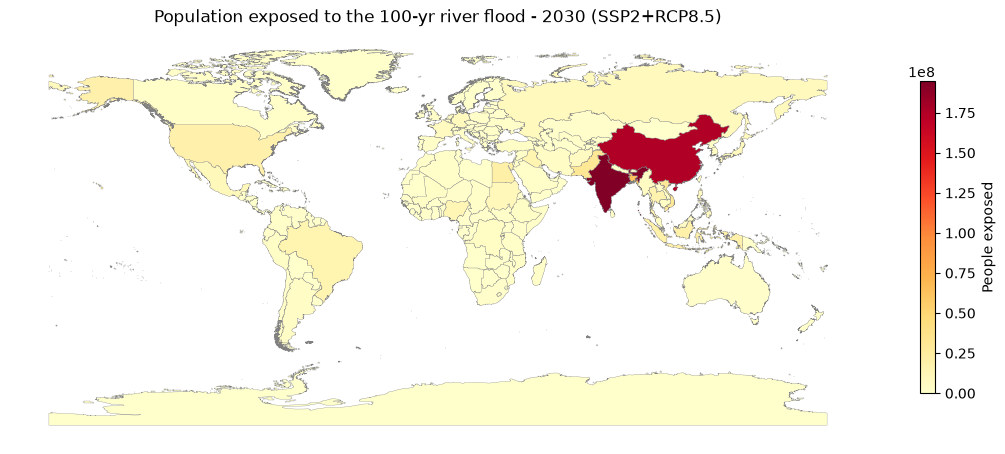

In [3]:
ax = pop30.plot(column="rp_100", cmap="YlOrRd", legend=True,
    legend_kwds={"label": "People exposed", "shrink": 0.6},
    figsize=(11, 5.5), edgecolor="grey", linewidth=0.2,
    missing_kwds={"color": "#eeeeee"})
ax.set_title("Population exposed to the 100-yr river flood - 2030 (SSP2+RCP8.5)")
ax.set_axis_off(); plt.tight_layout(); plt.show()

The exposure concentrates in the large, densely-populated river deltas of South and East Asia — the pattern the raw table below confirms.

In [4]:
pop30[["unit_name", "rp_100"]].sort_values("rp_100", ascending=False).head(8).reset_index(drop=True)

,unit_name,rp_100
0,INDIA,194649632.0
1,CHINA,175204534.4
2,BANGLADESH,62675597.6
3,PAKISTAN,31048267.6
4,VIET NAM,29125134.8
5,EGYPT,20578658.3
6,INDONESIA,19225120.6
7,UNITED STATES,18592117.6


## Choose the risk metric

The same request shape swaps `metric=` between the three exposure measures. These reuse the cached country shapefile — no new download. Top-5 countries by each metric (2030, SSP2+RCP8.5, 100-yr):

In [5]:
def top5(metric):
    fc = EarthLens("aqueduct", admin_level="country", metric=metric, year=2030,
        scenario="ssp2-rcp8p5", return_period=100, path=DATA, cache_dir=DATA).download()
    return fc.sort_values("rp_100", ascending=False).head(5).set_index("unit_name")["rp_100"]

metrics = ["population_affected", "gdp_affected", "urban_damage"]
tops = {m: top5(m) for m in metrics}

2026-08-09 23:19:47.681 | INFO     | earthlens.aqueduct.backend:_cached_zip:301 - Aqueduct: using cached aqueduct_global_flood_risk_data_by_country_20150304.zip


2026-08-09 23:19:48.114 | INFO     | earthlens.aqueduct.backend:download:341 - Aqueduct country/population_affected/2030/ssp2-rcp8p5: 253 unit(s).


2026-08-09 23:19:48.115 | INFO     | earthlens.aqueduct.backend:download:345 - Aqueduct source: World Resources Institute 2015; Winsemius et al. 2013; Ward et al. 2013 (licence CC-BY-4.0).


2026-08-09 23:19:48 | INFO | pyogrio._io | Created 253 records


2026-08-09 23:19:49.049 | INFO     | earthlens.aqueduct.backend:download:355 - Aqueduct: wrote 253 unit(s) to C:\python-environments\worktrees\earthlens\aqueduct-flood-risk\docs\examples\aqueduct\out\aqueduct_country_population_affected_2030_ssp2-rcp8p5_rp100.gpkg


...

2026-08-09 23:19:49.823 | INFO     | earthlens.aqueduct.backend:_cached_zip:301 - Aqueduct: using cached aqueduct_global_flood_risk_data_by_country_20150304.zip


2026-08-09 23:19:50.237 | INFO     | earthlens.aqueduct.backend:download:341 - Aqueduct country/urban_damage/2030/ssp2-rcp8p5: 253 unit(s).


2026-08-09 23:19:50.238 | INFO     | earthlens.aqueduct.backend:download:345 - Aqueduct source: World Resources Institute 2015; Winsemius et al. 2013; Ward et al. 2013 (licence CC-BY-4.0).


2026-08-09 23:19:50 | INFO | pyogrio._io | Created 253 records


2026-08-09 23:19:50.658 | INFO     | earthlens.aqueduct.backend:download:355 - Aqueduct: wrote 253 unit(s) to C:\python-environments\worktrees\earthlens\aqueduct-flood-risk\docs\examples\aqueduct\out\aqueduct_country_urban_damage_2030_ssp2-rcp8p5_rp100.gpkg


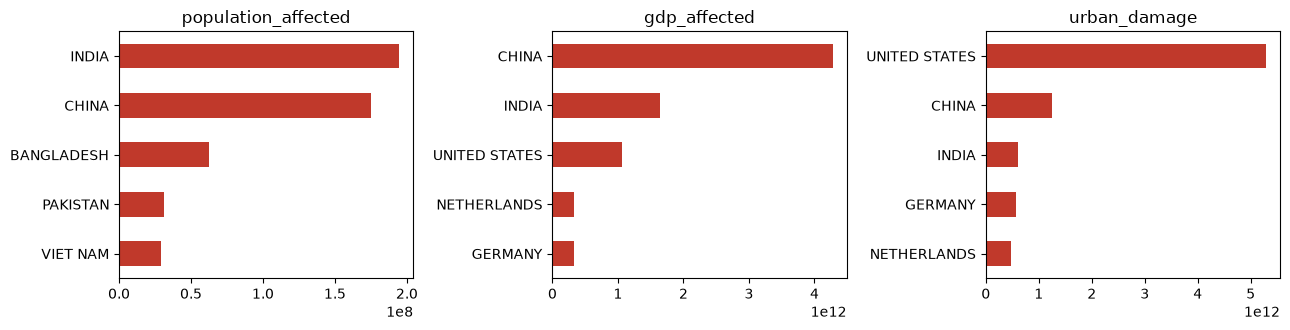

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, m in zip(axes, metrics):
    tops[m].iloc[::-1].plot.barh(ax=ax, color="#c0392b")
    ax.set_title(m); ax.set_ylabel("")
plt.tight_layout(); plt.show()

Population, GDP and urban-damage exposure rank countries differently — GDP exposure lifts wealthier economies, urban damage tracks built-up area. Pick the metric that matches your question.

## Baseline vs future

Set `year=2010, scenario="baseline"` for the current baseline, or a 2030 scenario for a projection. Comparing global totals shows how much the 100-year-flood population exposure grows by 2030 under SSP2+RCP8.5.

In [7]:
base10 = EarthLens("aqueduct", admin_level="country", metric="population_affected",
    year=2010, scenario="baseline", return_period=100, path=DATA, cache_dir=DATA).download()

totals = {"2010 baseline": float(base10["rp_100"].sum()),
          "2030 SSP2+RCP8.5": float(pop30["rp_100"].sum())}
totals

2026-08-09 23:19:51.033 | INFO     | earthlens.aqueduct.backend:_cached_zip:301 - Aqueduct: using cached aqueduct_global_flood_risk_data_by_country_20150304.zip


2026-08-09 23:19:51.416 | INFO     | earthlens.aqueduct.backend:download:341 - Aqueduct country/population_affected/2010/baseline: 253 unit(s).


2026-08-09 23:19:51.416 | INFO     | earthlens.aqueduct.backend:download:345 - Aqueduct source: World Resources Institute 2015; Winsemius et al. 2013; Ward et al. 2013 (licence CC-BY-4.0).


2026-08-09 23:19:51 | INFO | pyogrio._io | Created 253 records


2026-08-09 23:19:51.869 | INFO     | earthlens.aqueduct.backend:download:355 - Aqueduct: wrote 253 unit(s) to C:\python-environments\worktrees\earthlens\aqueduct-flood-risk\docs\examples\aqueduct\out\aqueduct_country_population_affected_2010_baseline_rp100.gpkg


{'2010 baseline': 625185098.102015, '2030 SSP2+RCP8.5': 820648106.5656779}

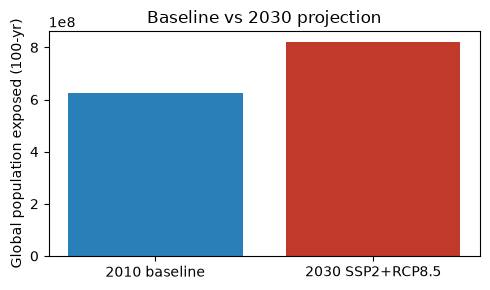

In [8]:
ax = plt.subplots(figsize=(5, 3))[1]
ax.bar(list(totals), list(totals.values()), color=["#2980b9", "#c0392b"])
ax.set_ylabel("Global population exposed (100-yr)")
ax.set_title("Baseline vs 2030 projection"); plt.tight_layout(); plt.show()

## The return-period curve

Omit `return_period` to get all nine flood magnitudes at once (`rp_2` … `rp_1000`). Exposure rises with the return period — rarer, larger floods reach more people. Here is the curve for the single most-exposed country.

In [9]:
allrp = EarthLens("aqueduct", admin_level="country", metric="population_affected",
    year=2030, scenario="ssp2-rcp8p5", path=DATA, cache_dir=DATA).download()

rp_cols = [c for c in allrp.columns if c.startswith("rp_")]
row = allrp.sort_values("rp_100", ascending=False).iloc[0]
periods = [int(c[3:]) for c in rp_cols]
row["unit_name"]

2026-08-09 23:19:52.046 | INFO     | earthlens.aqueduct.backend:_cached_zip:301 - Aqueduct: using cached aqueduct_global_flood_risk_data_by_country_20150304.zip


2026-08-09 23:19:52.492 | INFO     | earthlens.aqueduct.backend:download:341 - Aqueduct country/population_affected/2030/ssp2-rcp8p5: 253 unit(s).


2026-08-09 23:19:52.494 | INFO     | earthlens.aqueduct.backend:download:345 - Aqueduct source: World Resources Institute 2015; Winsemius et al. 2013; Ward et al. 2013 (licence CC-BY-4.0).


2026-08-09 23:19:52 | INFO | pyogrio._io | Created 253 records


2026-08-09 23:19:53.003 | INFO     | earthlens.aqueduct.backend:download:355 - Aqueduct: wrote 253 unit(s) to C:\python-environments\worktrees\earthlens\aqueduct-flood-risk\docs\examples\aqueduct\out\aqueduct_country_population_affected_2030_ssp2-rcp8p5_rp2-5-10-25-50-100-250-500-1000.gpkg


'INDIA'

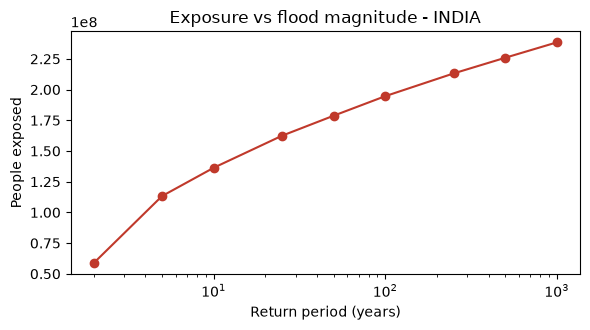

In [10]:
ax = plt.subplots(figsize=(6, 3.4))[1]
ax.plot(periods, [row[c] for c in rp_cols], marker="o", color="#c0392b")
ax.set_xscale("log"); ax.set_xlabel("Return period (years)")
ax.set_ylabel("People exposed"); ax.set_title("Exposure vs flood magnitude - " + row["unit_name"])
plt.tight_layout(); plt.show()

## Filter by country or bounding box

Pass `country=` (a country name, case-insensitive) to keep one unit, or `lat_lim`/`lon_lim` for a region. Both reuse the cache.

In [11]:
kenya = EarthLens("aqueduct", admin_level="country", country="Kenya",
    metric="population_affected", year=2030, scenario="ssp2-rcp8p5",
    return_period=[100, 500, 1000], path=DATA, cache_dir=DATA).download()
kenya[["unit_name", "rp_100", "rp_500", "rp_1000"]]

2026-08-09 23:19:53.564 | INFO     | earthlens.aqueduct.backend:_cached_zip:301 - Aqueduct: using cached aqueduct_global_flood_risk_data_by_country_20150304.zip


2026-08-09 23:19:54.225 | INFO     | earthlens.aqueduct.backend:download:341 - Aqueduct country/population_affected/2030/ssp2-rcp8p5: 1 unit(s).


2026-08-09 23:19:54.227 | INFO     | earthlens.aqueduct.backend:download:345 - Aqueduct source: World Resources Institute 2015; Winsemius et al. 2013; Ward et al. 2013 (licence CC-BY-4.0).


2026-08-09 23:19:54 | INFO | pyogrio._io | Created 1 records


2026-08-09 23:19:54.260 | INFO     | earthlens.aqueduct.backend:download:355 - Aqueduct: wrote 1 unit(s) to C:\python-environments\worktrees\earthlens\aqueduct-flood-risk\docs\examples\aqueduct\out\aqueduct_country_population_affected_2030_ssp2-rcp8p5_rp100-500-1000_Kenya.gpkg


,unit_name,rp_100,rp_500,rp_1000
117,KENYA,1.318464e+06,1.419013e+06,1.499566e+06


## Plain table output

Pass `geometry=False` to drop the geometry and get a `pandas.DataFrame` — handy for a spreadsheet export or a non-spatial analysis.

In [12]:
table = EarthLens("aqueduct", admin_level="country", metric="urban_damage",
    year=2010, scenario="baseline", return_period=100, path=DATA, cache_dir=DATA,
    geometry=False).download()
type(table).__name__, table.sort_values("rp_100", ascending=False).head(3).to_dict("records")

2026-08-09 23:19:54.280 | INFO     | earthlens.aqueduct.backend:_cached_zip:301 - Aqueduct: using cached aqueduct_global_flood_risk_data_by_country_20150304.zip


2026-08-09 23:19:54.699 | INFO     | earthlens.aqueduct.backend:download:341 - Aqueduct country/urban_damage/2010/baseline: 253 unit(s).


2026-08-09 23:19:54.699 | INFO     | earthlens.aqueduct.backend:download:345 - Aqueduct source: World Resources Institute 2015; Winsemius et al. 2013; Ward et al. 2013 (licence CC-BY-4.0).


('DataFrame',
 [{'unit_id': 239.0, 'unit_name': 'UNITED STATES', 'rp_100': 3124783740000.0},
  {'unit_id': 85.0, 'unit_name': 'GERMANY', 'rp_100': 433759912000.0},
  {'unit_id': 157.0, 'unit_name': 'NETHERLANDS', 'rp_100': 325275124000.0}])

## Takeaway

- One call shape — `admin_level` x `metric` x `year` x `scenario` x `return_period` — covers the whole product.
- Values are **per-return-period exposure**, not a single expected-annual figure.
- `admin_level="state"` / `"basin"` work the same way (each triggers its own download); `country=` filters by name, bbox filters any level.
- Coastal flooding and the 2050/2080 horizons are the paywalled 2020 product and are not available here.

Data: WRI Aqueduct Global Flood Analyzer 2015 (CC-BY-4.0). Attribution: *World Resources Institute 2015; Winsemius et al. 2013; Ward et al. 2013*. See the [reference pages](../../reference/aqueduct/introduction.md).